In [1]:
import os
import deeptile
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from deeptile.extensions import segmentation
from deeptile.extensions import stitch
matplotlib.rcParams['figure.dpi'] = 300
from tifffile import TiffFile
import tifffile
import dask.array as da

In [6]:
root = "/Users/hannahbolen/Desktop/image_analysis/"
# img_name = 'o8p_day18_s22.tif'
# img_name = 'o8p_day18.vsi'
img_name = "o8p_day24_s12.ome.tif"
img_path = os.path.join(root, img_name)
img = da.from_array(tifffile.imread(img_path))[0, 29500:29500+5120, 10700:10700+5120]
dt = deeptile.load(img)

In [7]:
# Configure
tile_size = (512, 512)
overlap = (0.1, 0.1)
# Get tiles
tiles = dt.get_tiles(tile_size, overlap)
tiles = tiles.pad()
# Individual tile
tiles[0, 0]

dask.array<getitem, shape=(512, 512), dtype=uint16, chunksize=(512, 512), chunktype=numpy.ndarray>

In [8]:
tiles.shape

(11, 11)

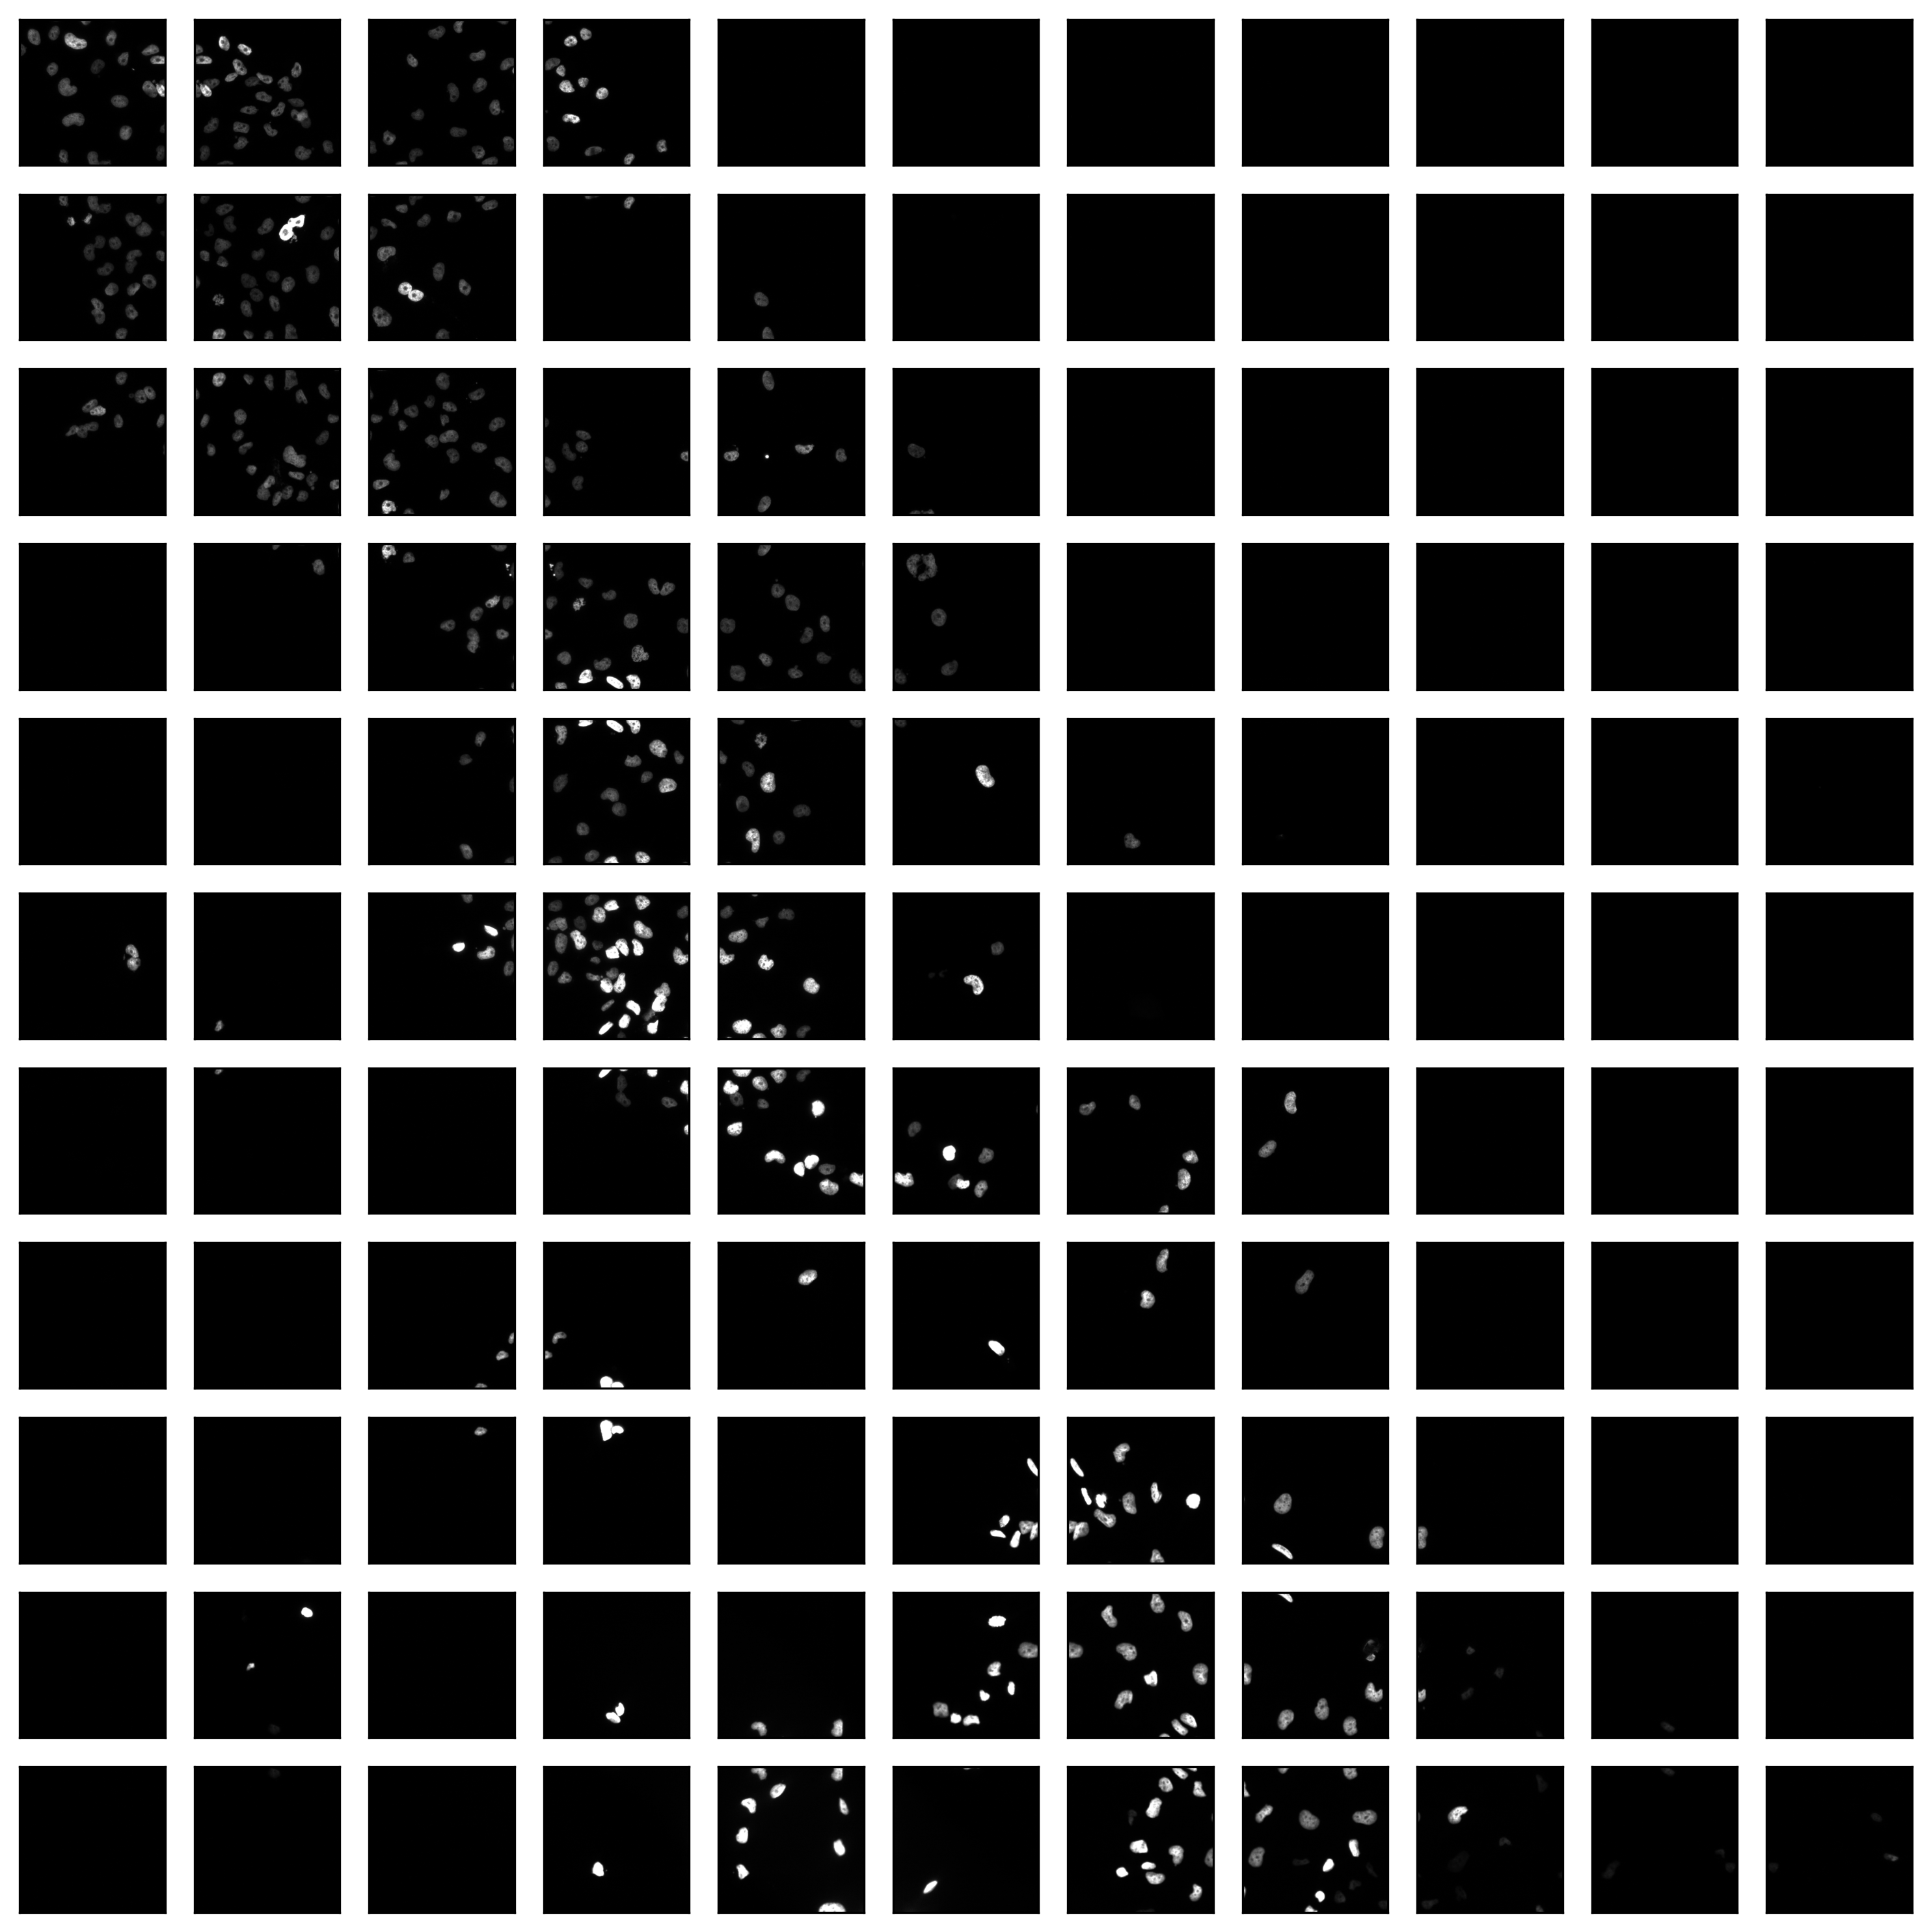

In [9]:
# Show the tiles
fig, ax = plt.subplots(tiles.shape[0], tiles.shape[1], figsize=(10, 10))
for (i, j), tile in np.ndenumerate(tiles):
    ax[i, j].imshow(tile, vmin=0, vmax=4000, cmap='gray')
    ax[i, j].set_xticks([])
    ax[i, j].set_yticks([])
plt.tight_layout()

In [10]:
# Segment tiles and stitch

model_parameters = {'gpu': True, 'model_type': 'nuclei'}
eval_parameters = {'diameter': 60}
cellpose = segmentation.cellpose_segmentation(model_parameters, eval_parameters)

masks = cellpose(tiles)
mask = stitch.stitch_masks(masks)

creating new log file
2026-03-05 17:05:09,292 [INFO] WRITING LOG OUTPUT TO /Users/hannahbolen/.cellpose/run.log
2026-03-05 17:05:09,292 [INFO] 
cellpose version: 	4.0.8 
platform:       	darwin 
python version: 	3.11.14 
torch version:  	2.9.1
2026-03-05 17:05:09,293 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-03-05 17:05:09,342 [INFO] ** TORCH MPS version installed and working. **
2026-03-05 17:05:09,343 [INFO] >>>> using GPU (MPS)
2026-03-05 17:05:09,934 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /Users/hannahbolen/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:35<00:00, 34.9MB/s]


2026-03-05 17:05:46,249 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:51,447 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:52,513 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:53,574 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:54,642 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:55,615 [INFO] No cell pixels found.
2026-03-05 17:05:55,625 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:56,687 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:57,660 [INFO] No cell pixels found.
2026-03-05 17:05:57,670 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:58,641 [INFO] No cell pixels found.
2026-03-05 17:05:58,651 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:05:59,625 [INFO] No cell pixels found.
2026-03-05 17:05:59,635 [INFO] processing grayscale image with (512, 512) HW
2026-03-05 17:06:0

In [11]:

# Data structures
print(mask.shape)
print(masks.shape)
print(tiles.shape)

(5120, 5120)
(11, 11)
(11, 11)


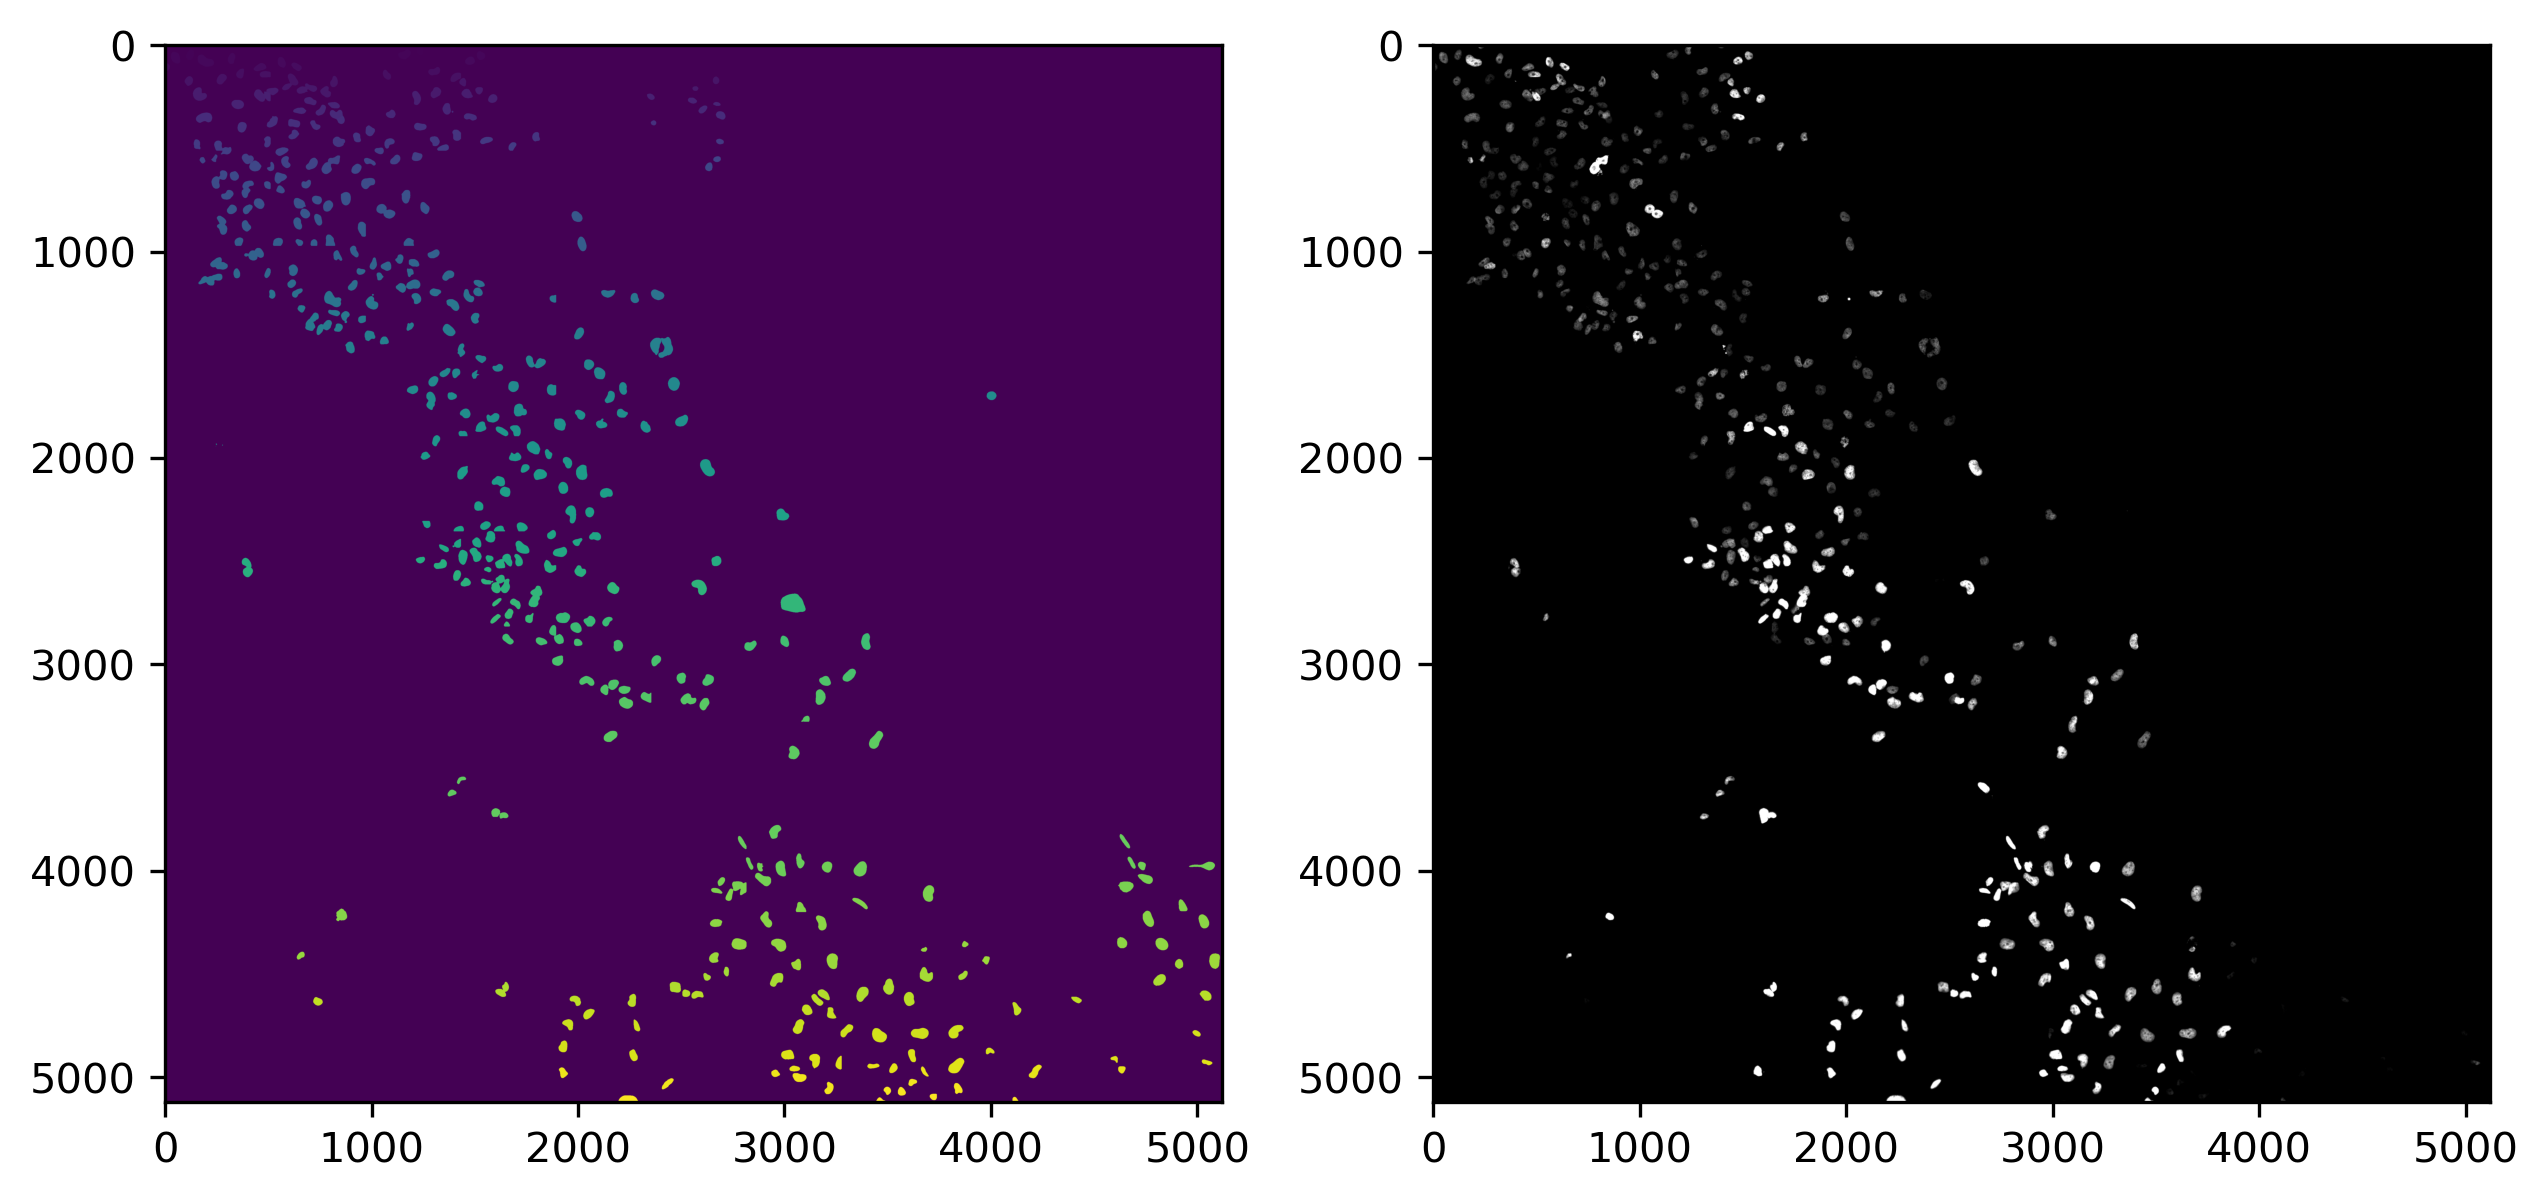

In [17]:
# Show the stitched mask
fig, ax = plt.subplots(figsize=(10, 10),ncols=2)
ax[0].imshow(mask)
ax[1].imshow(dt.image, vmin=256, vmax=3000, cmap='gray')

# ski.exposure.rescale_intensity(nucleiTile,in_range = (256, 12000))